# Fraud Detection Demo — WarehousePG + MADlib

Each stage's SQL lives directly in its own cell below (rather than being read from
`.sql` files on disk) -- run cells top to bottom the first time, then feel free to
jump back and re-run any single cell as needed (e.g. retrain without rebuilding data).

**Coming from Snowflake notebooks?** The main difference: Snowflake notebooks manage
your database session for you automatically. Here, you explicitly open a connection
in the cell below using `psycopg2` — that connection object (`conn`) is then reused
by every other cell in this notebook. If you restart the kernel, re-run that cell
first before anything else will work.


## Connect to WarehousePG

In [1]:
from sqlalchemy import create_engine
PGUSER="gpadmin"
PGHOST="cdw"
PGPORT="5432"
PGDATABASE="dev"
conn = create_engine(f"postgresql://{PGUSER}@{PGHOST}:{PGPORT}/{PGDATABASE}")

# If running elsewhere without trust auth, set a password and use this instead:
# PGPASSWORD="your_password_here"
# conn = create_engine(f"postgresql://{PGUSER}:{PGPASSWORD}@{PGHOST}:{PGPORT}/{PGDATABASE}")

%reload_ext sql
%sql conn

## Setup

In [2]:
%%sql
DROP SCHEMA IF EXISTS fraud_demo CASCADE;
DROP SCHEMA IF EXISTS fraud_demo_model CASCADE;
CREATE SCHEMA fraud_demo;
CREATE SCHEMA fraud_demo_model;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

++
||
++
++

## Create Dimensions

In [3]:
%%sql
CREATE TABLE fraud_demo.product_categories (
    category_id   int,
    category_name text,
    base_price    numeric,   -- typical price point for the category
    price_spread  numeric,   -- multiplier controlling price variance
    risk_weight   numeric    -- contribution to fraud probability (0-1 scale)
) DISTRIBUTED BY (category_id);

INSERT INTO fraud_demo.product_categories VALUES
 (1, 'Electronics',     450.00, 3.5, 0.35), -- high risk
 (2, 'Apparel',          60.00, 2.0, 0.05),
 (3, 'Footwear',         85.00, 1.8, 0.05),
 (4, 'Home Goods',      120.00, 2.5, 0.10), 
 (5, 'Gift Cards',      100.00, 4.0, 0.45), -- high risk
 (6, 'Beauty',           45.00, 1.5, 0.08),
 (7, 'Sporting Goods',  150.00, 2.2, 0.10),
 (8, 'Jewelry',         600.00, 5.0, 0.40); -- high rish

CREATE TABLE fraud_demo.payment_methods (
    method_id   int,
    method_name text,
    risk_weight numeric
) DISTRIBUTED BY (method_id);

INSERT INTO fraud_demo.payment_methods VALUES
 (1, 'credit_card',       0.20),
 (2, 'debit_card',        0.08),
 (3, 'digital_wallet',    0.15),
 (4, 'gift_card_balance', 0.35), -- high risk
 (5, 'buy_now_pay_later', 0.30); -- high risk

CREATE TABLE fraud_demo.countries (
    country_id   int,
    country_code text,
    is_high_risk boolean
) DISTRIBUTED BY (country_id);

INSERT INTO fraud_demo.countries VALUES
 (1, 'US', false),
 (2, 'CA', false),
 (3, 'GB', false),
 (4, 'DE', false),
 (5, 'AU', false),
 (6, 'NG', true), --high risk
 (7, 'RO', true), --high risk
 (8, 'VN', true); --high risk
CREATE TABLE fraud_demo.customers AS
SELECT
    c                                                    AS customer_id,
    (0.3 + random() * 3)::numeric(10,2)                  AS spend_multiplier,   -- some customers just spend more
    (floor(random() * 2000) + 1)::double precision        AS account_age_days,  -- double precision so MADlib treats it as continuous, not a ~2000-level categorical
    (floor(random() * 8) + 1)::int                        AS home_country_id,
    (random() < 0.02)                                     AS is_flagged_account -- ~2% pre-flagged risky accounts
FROM generate_series(1, 50000) AS c
DISTRIBUTED BY (customer_id);

Running query in 'postgresql://gpadmin@cdw:5432/dev'

8 rows affected.

5 rows affected.

8 rows affected.

50000 rows affected.

++
||
++
++

## Create Raw Transactions

In [4]:
%%sql
DROP TABLE IF EXISTS fraud_demo.transactions_raw;
CREATE TABLE fraud_demo.transactions_raw AS
SELECT
    base.*,
    CASE WHEN base.mismatch_roll < 0.92
         THEN base.billing_country_id                        -- 92% of the time shipping matches billing
         ELSE (floor(random() * 8) + 1)::int                  -- otherwise a mismatched country (fraud signal)
    END AS shipping_country_id
FROM (
    SELECT
        t                                                     AS transaction_id,
        (floor(random() * 50000) + 1)::int                    AS customer_id,
        (floor(random() * 8) + 1)::int                        AS category_id,
        (floor(random() * 5) + 1)::int                        AS payment_method_id,
        -- billing country weighted so high-risk countries (ids 6-8) are a realistic
        -- minority of traffic (~15%) rather than a uniform 3/8 = 37.5% of everything
        CASE WHEN random() < 0.85
             THEN (floor(random() * 5) + 1)::int   -- 85% of the time: one of the 5 low-risk countries
             ELSE (floor(random() * 3) + 6)::int    -- 15% of the time: one of the 3 high-risk countries
        END                                                   AS billing_country_id,
        random()                                              AS mismatch_roll,
        (floor(random() * 24))::int                           AS transaction_hour,
        now() - (random() * interval '90 days')               AS transaction_ts,
        (random() < 0.15)                                     AS is_new_device,
        (random() < 0.05)                                     AS is_new_shipping_address,
        (floor(random() * random() * 12))::int                AS txns_last_24h,   -- skewed: most 0-2, small tail much higher
        random()                                              AS noise_1,         -- jitter for fraud score
        random()                                              AS noise_2          -- final fraud roll
    FROM generate_series(1, 100000) AS t
) base
DISTRIBUTED BY (transaction_id);

Running query in 'postgresql://gpadmin@cdw:5432/dev'

100000 rows affected.

++
||
++
++

## Create Transactions (Join Dimensions to Raw Transactions)

In [5]:
%%sql
DROP TABLE IF EXISTS fraud_demo.transactions;
CREATE TABLE fraud_demo.transactions AS
SELECT
    base.transaction_id,
    base.customer_id,
    base.category_id,
    base.category_name,
    base.payment_method_id,
    base.payment_method_name,
    base.billing_country_id,
    base.billing_country_code,
    base.shipping_country_id,
    base.shipping_country_code,
    base.country_mismatch,
    base.transaction_hour,
    base.transaction_ts,
    base.is_new_device,
    base.is_new_shipping_address,
    base.shipping_country_high_risk,
    base.txns_last_24h,
    base.high_velocity,
    base.odd_hour,
    base.account_age_days,
    base.is_flagged_account,
    base.transaction_amount,
    base.true_fraud_probability,
    (CASE WHEN base.fraud_roll < base.true_fraud_probability THEN 1 ELSE 0 END) AS is_fraud
FROM (
    SELECT
        tr.transaction_id,
        tr.customer_id,
        tr.category_id,
        pc.category_name,
        tr.payment_method_id,
        pm.method_name                                             AS payment_method_name,
        tr.billing_country_id,
        bc.country_code                                            AS billing_country_code,
        tr.shipping_country_id,
        sc.country_code                                            AS shipping_country_code,
        (tr.billing_country_id <> tr.shipping_country_id)          AS country_mismatch,
        tr.transaction_hour,
        tr.transaction_ts,
        tr.is_new_device,
        tr.is_new_shipping_address,
        (sc.is_high_risk)                                           AS shipping_country_high_risk,
        tr.txns_last_24h,
        (tr.txns_last_24h > 5)                                      AS high_velocity,
        (tr.transaction_hour BETWEEN 1 AND 4)                       AS odd_hour,
        cu.account_age_days,
        cu.is_flagged_account,
        round(
            (pc.base_price * cu.spend_multiplier * (0.4 + power(random(), 2) * pc.price_spread))::numeric
        , 2)                                                        AS transaction_amount,
        -- ---- weighted fraud probability, sharpened MUCH more aggressively ----
        -- Two changes from the previous version, aimed at a demo-friendly ~90% AUC:
        --   1. Steepness raised from 10 to 25 -- this makes the sigmoid much closer
        --      to a hard on/off switch. Combinations below the midpoint get pushed
        --      almost all the way to 0; combinations above it get pushed almost all
        --      the way to 1. Very few land ambiguously in between.
        --   2. Jitter shrunk from +/-0.01 to +/-0.002 -- this was the main remaining
        --      source of irreducible randomness. Less jitter means less "genuine
        --      coin flip" territory, which directly raises the achievable ceiling.
        -- Together, these make is_fraud nearly a deterministic function of the risk
        -- factors -- closer to "if these flags are present, it IS fraud" than "if
        -- these flags are present, it's PROBABLY fraud." Re-run the ceiling check
        -- after rebuilding to confirm the new number before retraining the model.
        LEAST(GREATEST(
            1 / (1 + exp(-25 * (
                (
                    0.015
                    + pc.risk_weight * 0.05
                    + pm.risk_weight * 0.05
                    + CASE WHEN tr.billing_country_id <> tr.shipping_country_id THEN 0.15 ELSE 0 END
                    + CASE WHEN sc.is_high_risk THEN 0.15 ELSE 0 END
                    + CASE WHEN tr.is_new_device THEN 0.10 ELSE 0 END
                    + CASE WHEN tr.is_new_shipping_address THEN 0.10 ELSE 0 END
                    + CASE WHEN tr.txns_last_24h > 5 THEN 0.15 ELSE 0 END
                    + CASE WHEN tr.transaction_hour BETWEEN 1 AND 4 THEN 0.08 ELSE 0 END
                    + CASE WHEN cu.is_flagged_account THEN 0.30 ELSE 0 END
                    + (tr.noise_1 - 0.5) * 0.004
                ) - 0.55
            )))
        , 0.0), 1.0)                                                 AS true_fraud_probability,
        tr.noise_2                                                  AS fraud_roll
    FROM fraud_demo.transactions_raw tr
    JOIN fraud_demo.product_categories pc ON pc.category_id = tr.category_id
    JOIN fraud_demo.payment_methods    pm ON pm.method_id   = tr.payment_method_id
    JOIN fraud_demo.countries          bc ON bc.country_id  = tr.billing_country_id
    JOIN fraud_demo.countries          sc ON sc.country_id  = tr.shipping_country_id
    JOIN fraud_demo.customers          cu ON cu.customer_id = tr.customer_id
) base
DISTRIBUTED BY (transaction_id);

Running query in 'postgresql://gpadmin@cdw:5432/dev'

100000 rows affected.

++
||
++
++

## Create Transactions Train (80%) and Test (20%)

In [6]:
%%sql
DROP TABLE IF EXISTS fraud_demo.transactions_train;
DROP TABLE IF EXISTS fraud_demo.transactions_test;
CREATE TABLE fraud_demo.transactions_train AS
SELECT * FROM fraud_demo.transactions WHERE random() < 0.8
DISTRIBUTED BY (transaction_id);

CREATE TABLE fraud_demo.transactions_test AS
SELECT t.* FROM fraud_demo.transactions t
LEFT JOIN fraud_demo.transactions_train tr ON tr.transaction_id = t.transaction_id
WHERE tr.transaction_id IS NULL
DISTRIBUTED BY (transaction_id);


Running query in 'postgresql://gpadmin@cdw:5432/dev'

80145 rows affected.

19855 rows affected.

++
||
++
++

## Calculate Ceiling for Model

In [7]:
%%sql
DROP TABLE IF EXISTS fraud_demo.ceiling_auc;

SELECT madlib.area_under_roc(
       'fraud_demo.transactions_test',
       'fraud_demo.ceiling_auc',
       'true_fraud_probability',
       'is_fraud'
   );
SELECT * FROM fraud_demo.ceiling_auc;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

1 rows affected.

area_under_roc
0.975732830919145457364863441289057640425418880


## Train Random Forest Model
This takes less than 1 minute to execute.

In [8]:
%%time
%%sql
DROP TABLE IF EXISTS fraud_demo_model.fraud_rf_model, fraud_demo_model.fraud_rf_model_summary, fraud_demo_model.fraud_rf_model_group;

SELECT madlib.forest_train(
    'fraud_demo.transactions_train', -- input 
    'fraud_demo_model.fraud_rf_model', -- output
    'transaction_id',
    'is_fraud',
    'category_id, payment_method_id, country_mismatch, shipping_country_high_risk, -- features
     is_new_device, is_new_shipping_address, is_flagged_account,
     high_velocity, odd_hour',
    NULL,
    NULL,
    10, -- number of trees
    5,      -- num_random_features: 3 -> 5 (out of 9 features)
    FALSE,
    1,
    6,
    20,
    7,
    10,
    NULL,
    TRUE,
    1.0
);


Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

CPU times: user 12.6 ms, sys: 152 μs, total: 12.7 ms
Wall time: 35.9 s


## Show Model

- 10 rows because 10 trees were used
- bytea_length shows how large the binary model is for each tree

In [9]:
%%sql
SELECT gid, sample_id, length(tree::varchar) as bytea_length
FROM fraud_demo_model.fraud_rf_model;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

10 rows affected.

gid,sample_id,bytea_length
1,1,14266
1,2,14266
1,3,14266
1,4,14266
1,5,14266
1,6,14266
1,7,14266
1,8,14266
1,9,14266
1,10,14266


## Predict with Random Forest Model

In [10]:
%%sql
-- Class prediction (0/1)
DROP TABLE IF EXISTS fraud_demo.fraud_predictions_response;
SELECT madlib.forest_predict(
    'fraud_demo_model.fraud_rf_model', --model created with madlib
    'fraud_demo.transactions_test', --rows identified to be tested for fraud
    'fraud_demo.fraud_predictions_response', --output table name
    'response' --gives you the model's actual classification: a hard 0 or 1
);

-- Class probabilities (gives you a continuous fraud score, not just a flag)
DROP TABLE IF EXISTS fraud_demo.fraud_predictions_prob;
SELECT madlib.forest_predict(
    'fraud_demo_model.fraud_rf_model', --model created with madlib
    'fraud_demo.transactions_test', --rows identified to be tested for fraud
    'fraud_demo.fraud_predictions_prob', --output table name
    'prob' --the underlying score (probability)
);


Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

1 rows affected.

forest_predict
""


## Evaluate the Model

In [11]:
%%sql
DROP TABLE IF EXISTS fraud_demo.fraud_eval;
CREATE TABLE fraud_demo.fraud_eval AS
SELECT
    t.transaction_id,
    t.is_fraud                     AS actual,
    r.estimated_is_fraud::int      AS predicted,
    p.estimated_prob_1             AS fraud_score   -- probability of class "1" (fraud)
FROM fraud_demo.transactions_test t
JOIN fraud_demo.fraud_predictions_response r ON r.transaction_id = t.transaction_id
JOIN fraud_demo.fraud_predictions_prob     p ON p.transaction_id = t.transaction_id
DISTRIBUTED BY (transaction_id);

Running query in 'postgresql://gpadmin@cdw:5432/dev'

19855 rows affected.

++
||
++
++

## Check Accuracy

### Reading the raw output: `confusion_arr` and `area_under_roc`

The queries below return two outputs that look cryptic at first -- here's what each
one actually means before you run them.

**`confusion_arr` (from `fraud_confusion`)**

This table has one row per *actual* class, and `confusion_arr` is a 2-element array:
`[count predicted as "not fraud", count predicted as "fraud"]`.

| `class` | Meaning of the row | `confusion_arr[1]` | `confusion_arr[2]` |
|---|---|---|---|
| `0` | Transactions that were **actually not fraud** | # correctly approved | # wrongly flagged |
| `1` | Transactions that were **actually fraud** | # fraud missed entirely | # fraud correctly caught |

So `class=0`'s array is `[true negatives, false positives]`, and `class=1`'s array is
`[false negatives, true positives]`. It's the same information as a standard 2x2
confusion matrix, just returned as two rows of arrays instead of a labeled grid.
(The plain-English version of this same data -- `fraud_correctly_caught`,
`legit_wrongly_flagged`, etc. -- comes right after, and again in the Model
Performance Summary cell at the end, if the raw array format isn't intuitive.)

**`area_under_roc`**

A single number between 0 and 1 summarizing how well the model ranks risky
transactions above safe ones, across every possible decision threshold -- not just
the 0.5 cutoff used elsewhere in this notebook. 0.5 means no better than random
guessing; 1.0 means perfect separation. See the "Understanding Area Under ROC"
section later in this notebook for the full explanation, and the chart just below
for a visual of what the number actually represents.


In [12]:
%%sql
-- -------------------------------------------------------------------------------------
-- Confusion matrix: how the model's predictions broke down against actual outcomes
-- -------------------------------------------------------------------------------------
DROP TABLE IF EXISTS fraud_demo.fraud_confusion;
SELECT madlib.confusion_matrix(
    'fraud_demo.fraud_eval',
    'fraud_demo.fraud_confusion',
    'predicted',
    'actual'
);
-- -------------------------------------------------------------------------------------
-- AUC of the trained model's predictions (uses fraud_score -- the model's own estimate
-- of fraud probability for each transaction, learned from the training data)
-- -------------------------------------------------------------------------------------
DROP TABLE IF EXISTS fraud_demo.fraud_auc;
SELECT madlib.area_under_roc(
    'fraud_demo.fraud_eval',
    'fraud_demo.fraud_auc',
    'fraud_score',
    'actual'
);

-- -------------------------------------------------------------------------------------
-- AUC of the theoretical maximum (uses true_fraud_probability -- the EXACT probability
-- that was used to generate each transaction's is_fraud label in the first place).
-- No model, trained or hypothetical, can score higher than this on this dataset --
-- some transactions are inherently ambiguous by design, capping how good ANY model can be.
-- -------------------------------------------------------------------------------------
DROP TABLE IF EXISTS fraud_demo.ceiling_auc;
SELECT madlib.area_under_roc(
    'fraud_demo.transactions_test',
    'fraud_demo.ceiling_auc',
    'true_fraud_probability',
    'is_fraud'
);

-- -------------------------------------------------------------------------------------
-- Side-by-side comparison: what the model actually achieved vs. what was possible
-- -------------------------------------------------------------------------------------
SELECT
    comparison.score_source,
    comparison.auc_score,
    round(100.0 * comparison.auc_score
          / (SELECT area_under_roc FROM fraud_demo.ceiling_auc), 1) AS pct_of_theoretical_max
FROM (
    SELECT 'Random Forest Model (what was predicted)' AS score_source,
           round(area_under_roc::numeric, 4)           AS auc_score
    FROM fraud_demo.fraud_auc
    UNION ALL
    SELECT 'Theoretical Maximum (what was possible)'   AS score_source,
           round(area_under_roc::numeric, 4)           AS auc_score
    FROM fraud_demo.ceiling_auc
) comparison
ORDER BY comparison.score_source DESC;


Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

1 rows affected.

1 rows affected.

2 rows affected.

score_source,auc_score,pct_of_theoretical_max
Theoretical Maximum (what was possible),0.9757,100.0
Random Forest Model (what was predicted),0.7800,79.9


In [13]:
%%sql
-- -------------------------------------------------------------------------------------
-- Accuracy / confusion counts in plain SQL -- easiest thing to put on a demo slide
-- -------------------------------------------------------------------------------------
SELECT
    count(*)                                                        AS total_transactions_evaluated,
    sum(CASE WHEN predicted = actual THEN 1 ELSE 0 END)             AS correctly_classified,
    round(100.0 * sum(CASE WHEN predicted = actual THEN 1 ELSE 0 END)
          / count(*), 2)                                            AS overall_accuracy_pct,
    sum(CASE WHEN predicted = 1 AND actual = 1 THEN 1 ELSE 0 END)   AS fraud_correctly_caught,       -- true positives
    sum(CASE WHEN predicted = 1 AND actual = 0 THEN 1 ELSE 0 END)   AS legit_wrongly_flagged,        -- false positives
    sum(CASE WHEN predicted = 0 AND actual = 1 THEN 1 ELSE 0 END)   AS fraud_missed_entirely,        -- false negatives
    sum(CASE WHEN predicted = 0 AND actual = 0 THEN 1 ELSE 0 END)   AS legit_correctly_approved       -- true negatives
FROM fraud_demo.fraud_eval;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

total_transactions_evaluated,correctly_classified,overall_accuracy_pct,fraud_correctly_caught,legit_wrongly_flagged,fraud_missed_entirely,legit_correctly_approved
19855,19523,98.33,260,86,246,19263


In [14]:
%%sql
-- -------------------------------------------------------------------------------------
-- Precision / recall -- the metrics that actually matter for fraud
-- (recall = % of real fraud the model catches; precision = % of flags that are real fraud)
-- -------------------------------------------------------------------------------------
SELECT
    round(100.0 * sum(CASE WHEN predicted = 1 AND actual = 1 THEN 1 ELSE 0 END)
          / NULLIF(sum(CASE WHEN predicted = 1 THEN 1 ELSE 0 END), 0), 2) AS precision_pct_of_flags_are_real_fraud,
    round(100.0 * sum(CASE WHEN predicted = 1 AND actual = 1 THEN 1 ELSE 0 END)
          / NULLIF(sum(CASE WHEN actual = 1 THEN 1 ELSE 0 END), 0), 2)    AS recall_pct_of_real_fraud_caught
FROM fraud_demo.fraud_eval;


Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

precision_pct_of_flags_are_real_fraud,recall_pct_of_real_fraud_caught
75.14,51.38


Running query in 'postgresql://gpadmin@cdw:5432/dev'

19855 rows affected.

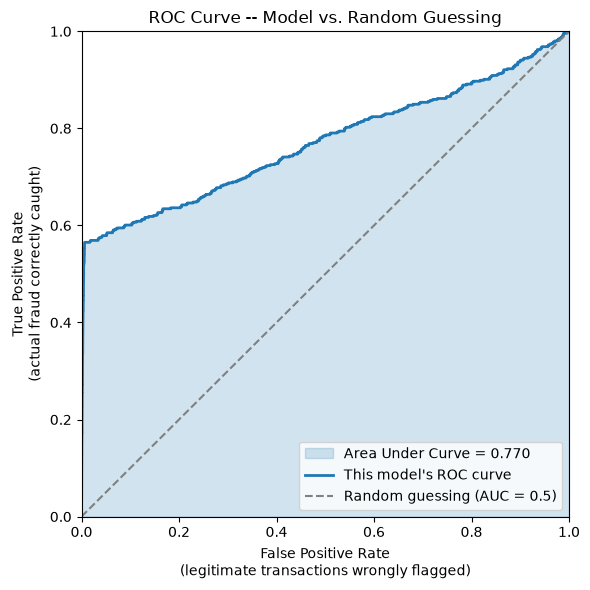

Area under this curve (AUC): 0.770


In [15]:
# Visualize the model's ROC curve, built directly from fraud_eval --
# no extra database query needed, this uses data already created in Stage 08.
import matplotlib.pyplot as plt
import numpy as np

result = %sql SELECT actual, fraud_score FROM fraud_demo.fraud_eval;
roc_df = result.DataFrame()
    
roc_df = roc_df.sort_values("fraud_score", ascending=False).reset_index(drop=True)

total_fraud = roc_df["actual"].sum()
total_legit = len(roc_df) - total_fraud

tpr = (roc_df["actual"].cumsum() / total_fraud).to_numpy()
fpr = (((roc_df["actual"] == 0).cumsum()) / total_legit).to_numpy()

tpr = np.concatenate([[0], tpr])
fpr = np.concatenate([[0], fpr])

model_auc = np.trapezoid(tpr, fpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(fpr, tpr, alpha=0.2, color="tab:blue", label=f"Area Under Curve = {model_auc:.3f}")
ax.plot(fpr, tpr, color="tab:blue", linewidth=2, label="This model\'s ROC curve")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")

ax.set_xlabel("False Positive Rate\n(legitimate transactions wrongly flagged)")
ax.set_ylabel("True Positive Rate\n(actual fraud correctly caught)")
ax.set_title("ROC Curve -- Model vs. Random Guessing")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Area under this curve (AUC): {model_auc:.3f}")


## Not Good Enough!
Area under the curve could be better so let's try another model. 

This is a common pattern with data science. Figuring out which model to use and also which parameters for the model requires many iterations. 

Utilizing more data and more compute, you can create a more accurate model. That is why WarehousePG is the ideal place for model training.

In a consumption based product like Snowflake, you may find yourself with a very large bill due to this activity.

## Logistic Regression
The random forest's ROC curve showed a specific pattern: it catches the most obvious
fraud cases very confidently, but is only slightly better than guessing on the rest.
That's a sign the underlying label doesn't fit a tree-based model well -- `is_fraud`
was generated as a sigmoid applied to a *weighted sum* of risk factors, which is
exactly the functional form logistic regression models directly and natively. Let's
test it on the same train/test split and compare.

In [16]:
%%sql
DROP TABLE IF EXISTS fraud_demo.fraud_logreg_model, fraud_demo.fraud_logreg_model_summary;

SELECT madlib.logregr_train(
    'fraud_demo.transactions_train',
    'fraud_demo.fraud_logreg_model',
    'is_fraud',
    'ARRAY[1, category_id, payment_method_id, country_mismatch::int, shipping_country_high_risk::int,
     is_new_device::int, is_new_shipping_address::int, is_flagged_account::int,
     high_velocity::int, odd_hour::int]'
);

DROP TABLE IF EXISTS fraud_demo.fraud_logreg_eval;
CREATE TABLE fraud_demo.fraud_logreg_eval AS
SELECT
    t.transaction_id,
    t.is_fraud AS actual,
    madlib.logregr_predict_prob(
        m.coef,
        ARRAY[1, t.category_id, t.payment_method_id, t.country_mismatch::int, t.shipping_country_high_risk::int,
              t.is_new_device::int, t.is_new_shipping_address::int, t.is_flagged_account::int,
              t.high_velocity::int, t.odd_hour::int]
    ) AS fraud_score
FROM fraud_demo.transactions_test t, fraud_demo.fraud_logreg_model m
DISTRIBUTED BY (transaction_id);

DROP TABLE IF EXISTS fraud_demo.fraud_logreg_auc;
SELECT madlib.area_under_roc('fraud_demo.fraud_logreg_eval', 'fraud_demo.fraud_logreg_auc', 'fraud_score', 'actual');
SELECT * FROM fraud_demo.fraud_logreg_auc;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

19855 rows affected.

1 rows affected.

1 rows affected.

area_under_roc
0.973945349996128937632514487968758586046725720


Running query in 'postgresql://gpadmin@cdw:5432/dev'

19855 rows affected.

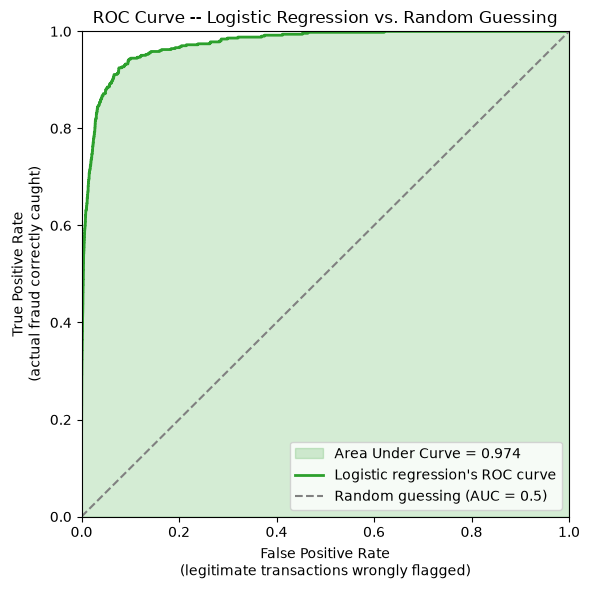

Area under this curve (AUC): 0.974


In [17]:
# Visualize the logistic regression model's ROC curve, built directly from
# fraud_logreg_eval -- same approach as the random forest chart above.
import matplotlib.pyplot as plt
import numpy as np

result = %sql SELECT actual, fraud_score FROM fraud_demo.fraud_logreg_eval;
roc_df = result.DataFrame()

roc_df = roc_df.sort_values("fraud_score", ascending=False).reset_index(drop=True)

total_fraud = roc_df["actual"].sum()
total_legit = len(roc_df) - total_fraud

tpr = (roc_df["actual"].cumsum() / total_fraud).to_numpy()
fpr = (((roc_df["actual"] == 0).cumsum()) / total_legit).to_numpy()

tpr = np.concatenate([[0], tpr])
fpr = np.concatenate([[0], fpr])


logreg_auc = np.trapezoid(tpr, fpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(fpr, tpr, alpha=0.2, color="tab:green", label=f"Area Under Curve = {logreg_auc:.3f}")
ax.plot(fpr, tpr, color="tab:green", linewidth=2, label="Logistic regression's ROC curve")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")

ax.set_xlabel("False Positive Rate\n(legitimate transactions wrongly flagged)")
ax.set_ylabel("True Positive Rate\n(actual fraud correctly caught)")
ax.set_title("ROC Curve -- Logistic Regression vs. Random Guessing")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Area under this curve (AUC): {logreg_auc:.3f}")

## Incoming Transactions
Use Logistic Regression model to detect fraud.

In [18]:
%%sql
DROP TABLE IF EXISTS fraud_demo.incoming_transactions;
CREATE TABLE fraud_demo.incoming_transactions (
    transaction_id              int,
    category_id                 int,
    payment_method_id           int,
    country_mismatch            boolean,
    shipping_country_high_risk  boolean,
    is_new_device                boolean,
    is_new_shipping_address      boolean,
    txns_last_24h                int,
    high_velocity                boolean,
    transaction_hour             int,
    odd_hour                     boolean,
    transaction_amount           numeric,
    account_age_days             double precision,
    is_flagged_account           boolean,
    scenario_label                text   -- not used by the model, just labels the row for the demo narration
) DISTRIBUTED BY (transaction_id);
INSERT INTO fraud_demo.incoming_transactions VALUES
-- Clearly clean transactions -- should score low, APPROVE
(900001, 2, 1, false, false, false, false, 1, false, 14, false,   45.00, 820, false, 'Regular apparel purchase, established account'),
(900002, 3, 2, false, false, false, false, 2, false, 16, false,   72.50, 1400, false, 'Footwear purchase, longtime customer'),
-- Clearly risky transactions -- multiple stacked factors, should score high, FLAG FOR REVIEW
(900003, 8, 4, true,  true,  true,  true,  9, true,  2,  true,  1850.00, 6,   true,  'Jewelry, gift-card balance, new device+address, high velocity, 2am, flagged account'),
(900004, 5, 4, true,  true,  true,  false, 7, true,  3,  true,   640.00, 12,  true,  'Gift card purchase, mismatched high-risk country, flagged account, odd hour'),
-- Borderline / mixed-risk transactions -- 1-2 factors, good for showing the "grey zone"
(900005, 1, 1, false, false, true,  false, 2, false, 20, false,  510.00, 300, false, 'Electronics, new device only'),
(900006, 4, 3, true,  false, false, false, 3, false, 11, false,  110.00, 950, false, 'Home goods, shipping/billing mismatch only'),
(900007, 8, 5, false, false, false, false, 6, true,  15, false,  620.00, 40,  false, 'Jewelry, high velocity only'),
(900008, 6, 1, false, false, false, false, 1, false, 9,  false,   38.00, 1100, false, 'Beauty product, otherwise clean');

SELECT
    i.transaction_id,
    i.scenario_label,
    round(
        madlib.logregr_predict_prob(
            m.coef,
            ARRAY[1, i.category_id, i.payment_method_id, i.country_mismatch::int, i.shipping_country_high_risk::int,
                  i.is_new_device::int, i.is_new_shipping_address::int, i.is_flagged_account::int,
                  i.high_velocity::int, i.odd_hour::int]
        )::numeric, 4
    ) AS fraud_score,
    CASE WHEN madlib.logregr_predict_prob(
            m.coef,
            ARRAY[1, i.category_id, i.payment_method_id, i.country_mismatch::int, i.shipping_country_high_risk::int,
                  i.is_new_device::int, i.is_new_shipping_address::int, i.is_flagged_account::int,
                  i.high_velocity::int, i.odd_hour::int]
        ) >= 0.3 THEN 'FLAG FOR REVIEW' ELSE 'APPROVE' END AS decision,
    array_to_string(
        array_remove(ARRAY[
            CASE WHEN i.country_mismatch           THEN 'billing/shipping country mismatch' END,
            CASE WHEN i.shipping_country_high_risk THEN 'shipping to a high-risk country' END,
            CASE WHEN i.is_new_device              THEN 'new device' END,
            CASE WHEN i.is_new_shipping_address     THEN 'new shipping address' END,
            CASE WHEN i.high_velocity               THEN 'unusually high purchase velocity (>5 in 24h)' END,
            CASE WHEN i.odd_hour                    THEN 'purchase made between 1-4am' END,
            CASE WHEN i.is_flagged_account           THEN 'account previously flagged' END
        ], NULL),
        ', '
    ) AS risk_factors_present
FROM fraud_demo.incoming_transactions i, fraud_demo.fraud_logreg_model m
ORDER BY fraud_score DESC;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

8 rows affected.

8 rows affected.

transaction_id,scenario_label,fraud_score,decision,risk_factors_present
900003,"Jewelry, gift-card balance, new device+address, high velocity, 2am, flagged account",1.0000,FLAG FOR REVIEW,"billing/shipping country mismatch, shipping to a high-risk country, new device, new shipping address, unusually high purchase velocity (>5 in 24h), purchase made between 1-4am, account previously flagged"
900004,"Gift card purchase, mismatched high-risk country, flagged account, odd hour",1.0000,FLAG FOR REVIEW,"billing/shipping country mismatch, shipping to a high-risk country, new device, unusually high purchase velocity (>5 in 24h), purchase made between 1-4am, account previously flagged"
900007,"Jewelry, high velocity only",0.0001,APPROVE,unusually high purchase velocity (>5 in 24h)
900006,"Home goods, shipping/billing mismatch only",0.0001,APPROVE,billing/shipping country mismatch
900001,"Regular apparel purchase, established account",0.0000,APPROVE,
900002,"Footwear purchase, longtime customer",0.0000,APPROVE,
900005,"Electronics, new device only",0.0000,APPROVE,new device
900008,"Beauty product, otherwise clean",0.0000,APPROVE,


## Model Performance Summary

Convenience cell -- pulls the AUC comparison and confusion matrix into clean,
labeled output. Requires Stage 09 to have already run.


In [19]:
import pandas as pd
from IPython.display import display

rf_auc_result = %sql SELECT area_under_roc FROM fraud_demo.fraud_auc;
rf_auc = float(rf_auc_result.DataFrame().iloc[0, 0])

rf_metrics_result = %sql SELECT round(100.0 * sum(CASE WHEN predicted = actual THEN 1 ELSE 0 END) / count(*), 2) AS accuracy_pct, round(100.0 * sum(CASE WHEN predicted = 1 AND actual = 1 THEN 1 ELSE 0 END) / NULLIF(sum(CASE WHEN predicted = 1 THEN 1 ELSE 0 END), 0), 2) AS precision_pct, round(100.0 * sum(CASE WHEN predicted = 1 AND actual = 1 THEN 1 ELSE 0 END) / NULLIF(sum(CASE WHEN actual = 1 THEN 1 ELSE 0 END), 0), 2) AS recall_pct FROM fraud_demo.fraud_eval;
rf_accuracy, rf_precision, rf_recall = rf_metrics_result.DataFrame().iloc[0]

rf_confusion_result = %sql SELECT class, confusion_arr FROM fraud_demo.fraud_confusion ORDER BY class;
rf_confusion_rows_data = list(rf_confusion_result.DataFrame()["confusion_arr"])

logreg_auc_result = %sql SELECT area_under_roc FROM fraud_demo.fraud_logreg_auc;
logreg_auc = float(logreg_auc_result.DataFrame().iloc[0, 0])

logreg_metrics_result = %sql SELECT round(100.0 * sum(CASE WHEN (fraud_score >= 0.3)::int = actual THEN 1 ELSE 0 END) / count(*), 2) AS accuracy_pct, round(100.0 * sum(CASE WHEN fraud_score >= 0.3 AND actual = 1 THEN 1 ELSE 0 END) / NULLIF(sum(CASE WHEN fraud_score >= 0.3 THEN 1 ELSE 0 END), 0), 2) AS precision_pct, round(100.0 * sum(CASE WHEN fraud_score >= 0.3 AND actual = 1 THEN 1 ELSE 0 END) / NULLIF(sum(CASE WHEN actual = 1 THEN 1 ELSE 0 END), 0), 2) AS recall_pct FROM fraud_demo.fraud_logreg_eval;
logreg_accuracy, logreg_precision, logreg_recall = logreg_metrics_result.DataFrame().iloc[0]

logreg_confusion_result = %sql SELECT sum(CASE WHEN actual = 0 AND fraud_score < 0.3 THEN 1 ELSE 0 END) AS tn, sum(CASE WHEN actual = 0 AND fraud_score >= 0.3 THEN 1 ELSE 0 END) AS fp, sum(CASE WHEN actual = 1 AND fraud_score < 0.3 THEN 1 ELSE 0 END) AS fn, sum(CASE WHEN actual = 1 AND fraud_score >= 0.3 THEN 1 ELSE 0 END) AS tp FROM fraud_demo.fraud_logreg_eval;
logreg_tn, logreg_fp, logreg_fn, logreg_tp = logreg_confusion_result.DataFrame().iloc[0]

ceiling_auc_result = %sql SELECT area_under_roc FROM fraud_demo.ceiling_auc;
ceiling_auc = float(ceiling_auc_result.DataFrame().iloc[0, 0])

# --- Comparison table ---
comparison_df = pd.DataFrame({
    "Metric": ["AUC", "% of Ceiling Achieved", "Accuracy", "Precision", "Recall"],
    "Random Forest": [
        f"{rf_auc:.3f}",
        f"{round(100.0 * rf_auc / ceiling_auc, 1)}%",
        f"{rf_accuracy}%",
        f"{rf_precision}%",
        f"{rf_recall}%",
    ],
    "Logistic Regression": [
        f"{logreg_auc:.3f}",
        f"{round(100.0 * logreg_auc / ceiling_auc, 1)}%",
        f"{logreg_accuracy}%",
        f"{logreg_precision}%",
        f"{logreg_recall}%",
    ],
})
print(f"Theoretical Max AUC (ceiling): {ceiling_auc:.3f}\n")
display(comparison_df)

# --- Confusion matrices, side by side ---
rf_conf_df = pd.DataFrame(
    rf_confusion_rows_data,
    index=["Actual: Not Fraud", "Actual: Fraud"],
    columns=["Predicted: Not Fraud", "Predicted: Fraud"],
)
logreg_conf_df = pd.DataFrame(
    [[logreg_tn, logreg_fp], [logreg_fn, logreg_tp]],
    index=["Actual: Not Fraud", "Actual: Fraud"],
    columns=["Predicted: Not Fraud", "Predicted: Fraud"],
)
print("Random Forest -- Confusion Matrix:")
display(rf_conf_df)
print("Logistic Regression -- Confusion Matrix:")
display(logreg_conf_df)

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

Running query in 'postgresql://gpadmin@cdw:5432/dev'

...

,Metric,Random Forest,Logistic Regression
0,AUC,0.780,0.974
1,% of Ceiling Achieved,79.9%,99.8%
2,Accuracy,98.33%,98.21%
3,Precision,75.14%,65.56%
4,Recall,51.38%,62.45%


Random Forest -- Confusion Matrix:


,Predicted: Not Fraud,Predicted: Fraud
Actual: Not Fraud,19263,86
Actual: Fraud,246,260


Logistic Regression -- Confusion Matrix:


,Predicted: Not Fraud,Predicted: Fraud
Actual: Not Fraud,19183,166
Actual: Fraud,190,316


## Close the connection

In [20]:
connection_url = f"postgresql://{PGUSER}@{PGHOST}:{PGPORT}/{PGDATABASE}"
%sql --close {{connection_url}}

# Finished!
You did it! You successfully loaded built two ML models using MADlib inside WarehousePG. 

Finding the right model with the right parameters can take many iterations and lots of data to be accurate. Using WarehousePG allows you to use more data and in parallel across the entire cluster.